# Simple Linear Regression (Hieght-Weight)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
# Read the dataset
df = pd.read_csv('height-weight.csv')

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
# First 5 entries
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


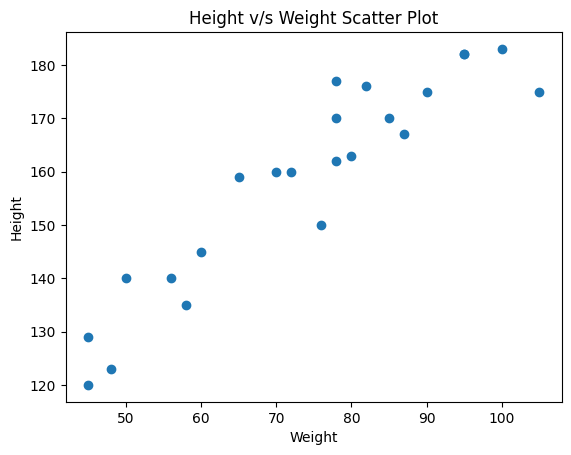

In [10]:
# Scatter plot
plt.scatter(x=df['Weight'],y=df['Height'])
plt.ylabel("Height")
plt.xlabel("Weight")
plt.title("Height v/s Weight Scatter Plot")
plt.show()

In [11]:
# Check for the correlation between two variables
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


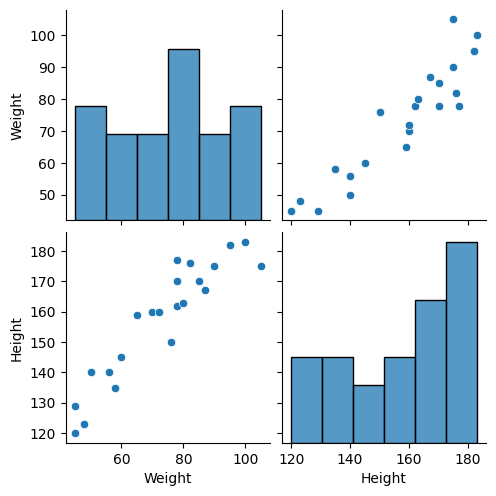

In [12]:
# Heatmap for the correlation
import seaborn as sns
sns.pairplot(df)

In [35]:
# Split independent and dependent features
X = df[['Weight']] # Splitting the independent feature in two dimensional array
y = df['Height'] # Splitting the dependent feature in one dimensional array

In [36]:
# Split the train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=42)

In [37]:
X_train.shape

(17, 1)

In [38]:
X_test.shape

(6, 1)

In [39]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
# APply linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression(n_jobs=-1)
model.fit(X_train_scaled,y_train)
y_predict = model.predict(X_test_scaled)

In [71]:
print(f"Coefficient or slope: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


In [42]:
y_predict

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [43]:
y_test

15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64

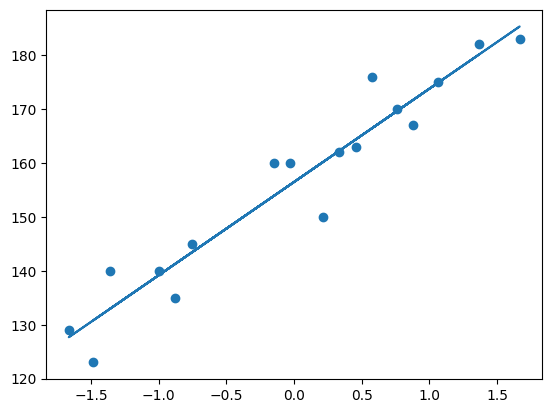

In [48]:
# Plot training data plot best fit line
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,model.predict(X_train_scaled))

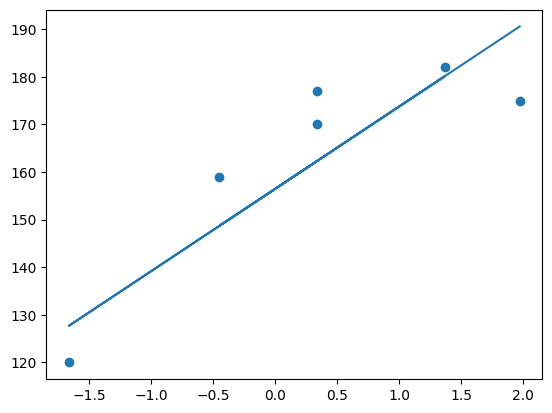

In [52]:
# Plot test data plot best fit line
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled, y_predict)

In [50]:
## Performance metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
mse = mean_squared_error(y_test,y_predict)
rmse = root_mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [51]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_predict)
print(score)

0.7360826717981276


In [55]:
# Adjusted r2 score
1 - (1-score) * (len(y_test)-1) / (len(y_test) - X_test.shape[1]-1)

0.6701033397476595

# OLS Linear Regression

In [61]:
import statsmodels.api as sm 

In [74]:
ols_model = sm.OLS(y_train, X_train_scaled).fit()
y_predict = ols_model.predict(X_test_scaled)

In [75]:
ols_model.summary()

c:\Users\battih\Desktop\Personal\Data Science\myvenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 21 Jun 2025   Prob (F-statistic):                       0.664
Time:                        16:56:02   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
# Prediction for new data
model.predict(scaler.transform([[72]]))

c:\Users\battih\Desktop\Personal\Data Science\myvenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])